In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import torch
from torch import nn

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")

In [3]:
df = pd.read_csv("Trek_Data.csv")

# Note: In the dataset, the first column name was empty, so to avoid the "Unnamed:0" column in the dataframe, we dropped it
unnamed_columns = [col for col in df.columns if str(col).startswith("Unnamed") or str(col).strip() == ""]
if unnamed_columns:
    df = df.drop(columns=unnamed_columns)

print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns.")
print(df.head(3).to_string(index=False)) # returns 383x8 shape




Loaded 383 rows and 8 columns.
                               Trek             Cost     Time Trip Grade Max Altitude     Accomodation         Best Travel Time       Contact or Book your Trip
             Everest Base Camp Trek \n$1,420     USD  16 Days   Moderate       5545 m Hotel/Guesthouse March - May & Sept - Dec https://www.nepalhikingteam.com
       Everest Base Camp Short Trek \n$1,295     USD  14 Days   Moderate       5545 m Hotel/Guesthouse March - May & Sept - Dec https://www.nepalhikingteam.com
Everest Base Camp Heli Shuttle Trek      \n$2000 USD  12 Days   Moderate       5545 m Hotel/Guesthouse March - May & Sept - Dec https://www.nepalhikingteam.com


In [4]:
import re
def extract_cost_usd(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"\$?\s*([0-9][0-9,]*(?:\.\d+)?)\s*(?:USD)?", str(value), flags=re.IGNORECASE)
    return float(match.group(1).replace(",", "")) if match else np.nan

def extract_duration_days(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"([0-9]+(?:\.\d+)?)\s*days?", str(value), flags=re.IGNORECASE)
    return float(match.group(1)) if match else np.nan

def extract_altitude_m(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"([0-9][0-9,]*(?:\.\d+)?)\s*m\b", str(value), flags=re.IGNORECASE)
    return float(match.group(1).replace(",", "")) if match else np.nan

df["Cost_USD"] = df["Cost"].apply(extract_cost_usd)
df["Duration_Days"] = df["Time"].apply(extract_duration_days)
df["Altitude_m"] = df["Max Altitude"].apply(extract_altitude_m)

engineered_columns = ["Cost_USD", "Duration_Days", "Altitude_m", "Trip Grade"]
rows_before_cleaning = len(df)
df = df.dropna(subset=engineered_columns).reset_index(drop=True)
rows_dropped = rows_before_cleaning - len(df)

print(f"Rows dropped: {rows_dropped}") # returns 0, so all columns contain non null values
print(f"Clean rows retained: {len(df)}")
print(df[["Trek", "Cost_USD", "Duration_Days", "Altitude_m", "Trip Grade"]].head(8).to_string(index=False))


Rows dropped: 0
Clean rows retained: 383
                               Trek  Cost_USD  Duration_Days  Altitude_m Trip Grade
             Everest Base Camp Trek    1420.0           16.0      5545.0   Moderate
       Everest Base Camp Short Trek    1295.0           14.0      5545.0   Moderate
Everest Base Camp Heli Shuttle Trek    2000.0           12.0      5545.0   Moderate
        Everest Base Camp Heli Trek    3300.0           11.0      5545.0   Moderate
 Everest Base Camp Trek for Seniors    1800.0           20.0      5545.0   Moderate
            Everest Chola Pass Trek    1720.0           19.0      5545.0  Strenuous
      Gokyo Lake Renjo La Pass Trek    1450.0           16.0      5360.0   Moderate
           Everest High Passes Trek    1950.0           22.0      5545.0  Strenuous


In [6]:
continuous_features = ["Duration_Days", "Altitude_m"]

scaler = StandardScaler()
X_raw = scaler.fit_transform(df[continuous_features].to_numpy(dtype=float))

print("Standardized continuous feature matrix X_raw")
print(f"Shape: {X_raw.shape}")
print(pd.DataFrame(X_raw, columns=continuous_features).describe().round(4).to_string())

Standardized continuous feature matrix X_raw
Shape: (383, 2)
       Duration_Days  Altitude_m
count       383.0000    383.0000
mean         -0.0000      0.0000
std           1.0013      1.0013
min          -2.1082     -3.0261
25%          -0.7856     -0.4996
50%          -0.1243      0.4013
75%           0.7574      0.7598
max           2.7413      1.6646


In [7]:
X_centered = X_raw - np.mean(X_raw, axis=0)

def kernel_pca_rbf_scratch(X, gamma=0.5, n_components=2):
    n = X.shape[0]
    sq_dists = np.sum(X**2, axis=1).reshape(-1, 1) + np.sum(X**2, axis=1) - 2 * (X @ X.T)
    K = np.exp(-gamma * sq_dists) 
    
    I_n = np.ones((n, n)) / n
    K_centered = K - I_n @ K - K @ I_n + I_n @ K @ I_n
    
    U, S, Vt = np.linalg.svd(K_centered)
    
    return U[:, :n_components] * np.sqrt(S[:n_components])

kpca_coordinates = kernel_pca_rbf_scratch(X_raw, gamma=0.3, n_components=2)
df["KPC1"] = kpca_coordinates[:, 0]
df["KPC2"] = kpca_coordinates[:, 1]


In [8]:
kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=10)
df["Terrain_Cluster"] = kmeans.fit_predict(kpca_coordinates)

cluster_archetype_matrix = df.groupby("Terrain_Cluster")[["Duration_Days", "Altitude_m", "Cost_USD"]].mean().sort_index()

print("Cluster Archetype Matrices: mean route profile by terrain category")
print(cluster_archetype_matrix.round(2).to_string())

Cluster Archetype Matrices: mean route profile by terrain category
                 Duration_Days  Altitude_m  Cost_USD
Terrain_Cluster                                     
0                        12.91     5244.66   1488.03
1                        10.87     3517.97   1178.98
2                        19.10     5231.82   1580.51


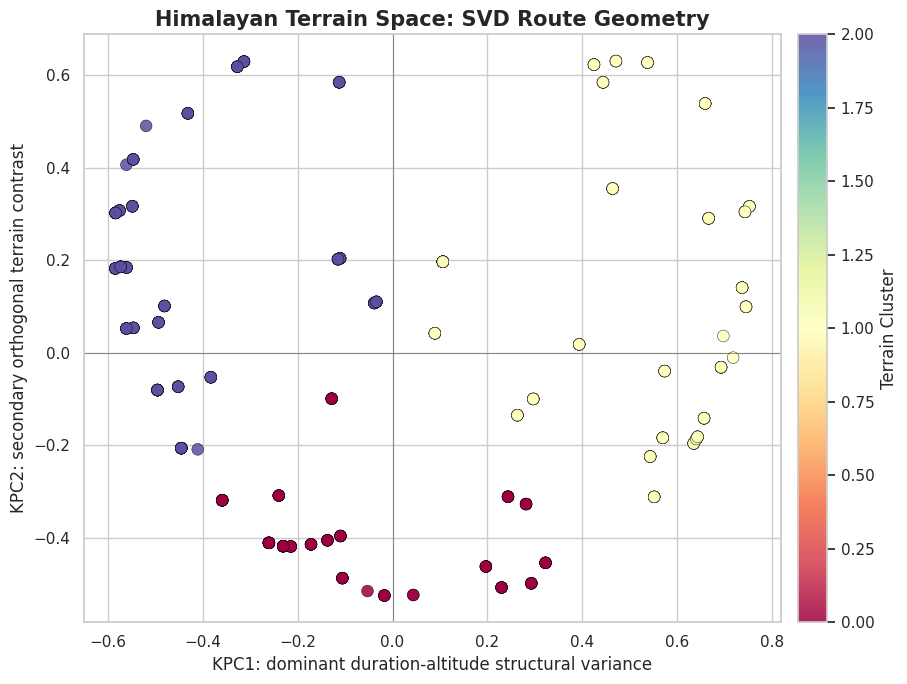

Saved SVD terrain visualization.


In [ ]:
fig, ax = plt.subplots(figsize=(9.5, 7.0))
scatter = ax.scatter(df["KPC1"], df["KPC2"], c=df["Terrain_Cluster"], cmap="Spectral", s=72, alpha=0.86, edgecolor="black", linewidth=0.35)

ax.set_title("Himalayan Terrain Space: SVD Route Geometry", fontsize=15, weight="bold")
ax.set_xlabel("KPC1: dominant duration-altitude structural variance")
ax.set_ylabel("KPC2: secondary orthogonal terrain contrast")
cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Terrain Cluster")
ax.axhline(0, color="black", linewidth=0.7, alpha=0.35)
ax.axvline(0, color="black", linewidth=0.7, alpha=0.35)
fig.tight_layout()
fig.savefig("kpca_terrain_space.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved KPCA terrain visualization.")

In [11]:
target_scaler = StandardScaler()
y_scaled = target_scaler.fit_transform(df[["Cost_USD"]].to_numpy()).astype(np.float32)

grade_dummies = pd.get_dummies(df["Trip Grade"], drop_first=False).to_numpy().astype(np.float32)
grade_map = {
    'Easy': 1, 'Light': 1, 'Easy-Moderate': 1, 'Easy To Moderate': 1, 'Light+Moderate': 1,
    'Moderate': 2, 'Moderate+Demanding': 2, 'Moderate-Hard': 2,
    'Strenuous': 3, 'Demanding': 3,
    'Demanding+Challenging': 4
}
df['Difficulty_Tier'] = df['Trip Grade'].map(grade_map).fillna(2).astype(np.float32)
X_nn = np.hstack((kpca_coordinates.astype(np.float32), df[['Difficulty_Tier']].to_numpy()))
y_cost = df["Cost_USD"].to_numpy(dtype=np.float32).reshape(-1, 1)

X_tensor = torch.tensor(X_nn, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

print(f"Fused neural input matrix X_nn shape: {X_nn.shape}")
print(f"Target tensor shape: {tuple(y_tensor.shape)}")

Fused neural input matrix X_nn shape: (383, 3)
Target tensor shape: (383, 1)


In [12]:
class TrekCostRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.network(x)

model = TrekCostRegressor(input_dim=X_nn.shape[1])
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

loss_history = []
model.train()
for epoch in range(150):
    optimizer.zero_grad()
    predictions = model(X_tensor)
    loss = criterion(predictions, y_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(float(loss.item()))

    if (epoch + 1) % 25 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1:03d}/150 | MSE Loss: {loss.item():,.4f}")

print(f"Final training MSE after 150 iterations: {loss_history[-1]:,.4f}")

/home/raksha/code/capstone_project/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:882: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 001/150 | MSE Loss: 0.3652
Epoch 025/150 | MSE Loss: 0.2552
Epoch 050/150 | MSE Loss: 0.2462
Epoch 075/150 | MSE Loss: 0.2387
Epoch 100/150 | MSE Loss: 0.2145
Epoch 125/150 | MSE Loss: 0.2034
Epoch 150/150 | MSE Loss: 0.1952
Final training MSE after 150 iterations: 0.1952


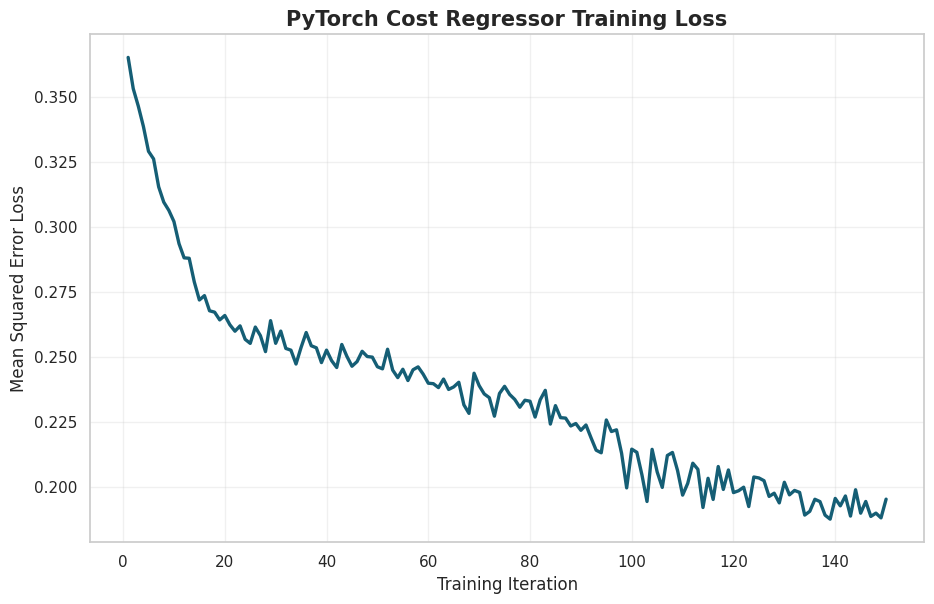

Saved training convergence visualization.


In [13]:
fig, ax = plt.subplots(figsize=(9.5, 6.2))
ax.plot(np.arange(1, len(loss_history) + 1), loss_history, color="#155e75", linewidth=2.4)
ax.set_title("PyTorch Cost Regressor Training Loss", fontsize=15, weight="bold")
ax.set_xlabel("Training Iteration")
ax.set_ylabel("Mean Squared Error Loss")
ax.grid(True, alpha=0.28)
fig.tight_layout()
fig.savefig("training_loss_convergence.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved training convergence visualization.")